In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

In [2]:
# fetch data
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"]
print(y)
print(X[1])

['5' '0' '4' ... '4' '5' '6']
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0  51 159 253 159  50   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0  48 238 252 252 252 237   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0  54 227 253 252 239 233 252  57   6   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202  84 252
 253 122   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0 163 252 252 252 

In [3]:
#X is uint8 ==> turn to float to divide and store back
#y turns fro char to float ==>turn it to int
X=X.astype(float)
X/=255.0
y=(y=='8').astype(int)

print(y)
print(X[1])

[0 0 0 ... 0 0 0]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.  

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [6]:
def calculate_gradient(theta, X, y):
    m=y.size
    return X.T @ (sigmoid(X@theta)-y)/m


In [7]:
def predict_prob(X, theta):
        X_b=np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)
        return sigmoid(X_b @ theta)


In [8]:
def gradient_descent(X, y, alpha=0.1, num_iter=100, tolerance=1e-7):
    X_b=np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)
    theta=np.zeros(X_b.shape[1])
    for i in range(num_iter):
        grad=calculate_gradient(theta,X_b,y)
        theta-=alpha*grad
        if np.linalg.norm(grad)<tolerance:
            break
    return theta

In [9]:

def predict(X, theta, threshold=0.5):
    return (predict_prob(X, theta)>=threshold).astype(int)

In [10]:
theta_hat=gradient_descent(X_train,y_train,alpha=0.1)
print(theta_hat)

[-3.57647784e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -9.85578534e-06 -3.39038995e-05 -1.37132838e-05
 -5.71386826e-07  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -5.02854591e-07 -6.11255271e-06 -3.93675417e-05
 -4.86336336e-05 -7.84146798e-05 -1.50507558e-04 -2.94886382e-04
 -3.89834869e-04 -4.99812049e-04 -5.65243252e-04 -6.21238996e-04
 -5.15309540e-04 -5.34220819e-04 -4.73307537e-04 -2.70144773e-04
 -1.59743126e-04 -1.43665744e-04 -5.60416553e-05 -2.22607837e-05
 -1.21679899e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -6.06617333e-07 -1.54115

In [11]:
y_pred_train=predict(X_train,theta_hat)
y_pred_test=predict(X_test,theta_hat)


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,ConfusionMatrixDisplay
train_acc=accuracy_score(y_train,y_pred_train)
test_acc=accuracy_score(y_test,y_pred_test)
print("train_acc: ",train_acc)
print("test_acc: ",test_acc)

train_acc:  0.9261785714285714
test_acc:  0.9269285714285714


In [13]:
train_per=precision_score(y_train,y_pred_train)
test_per=precision_score(y_test,y_pred_test)
print("train_per: ",train_per)
print("test_per: ",test_per)

train_per:  0.8108108108108109
test_per:  0.8223938223938224


In [14]:
train_recall=recall_score(y_train,y_pred_train)
test_recall=recall_score(y_test,y_pred_test)
print("train_recall: ",train_recall)
print("test_recall: ",test_recall)


train_recall:  0.3182150694952451
test_recall:  0.313927781871776


In [15]:
train_f1=f1_score(y_train,y_pred_train)
test_f1=f1_score(y_test,y_pred_test)
print("train_f1: ",train_f1)
print("test_f1: ",test_f1)


train_f1:  0.4570527974783294
test_f1:  0.4544


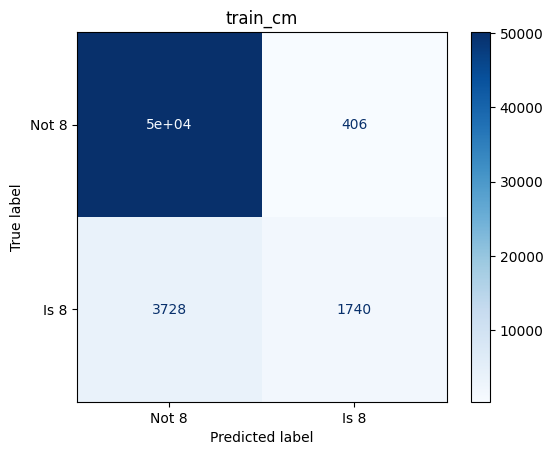

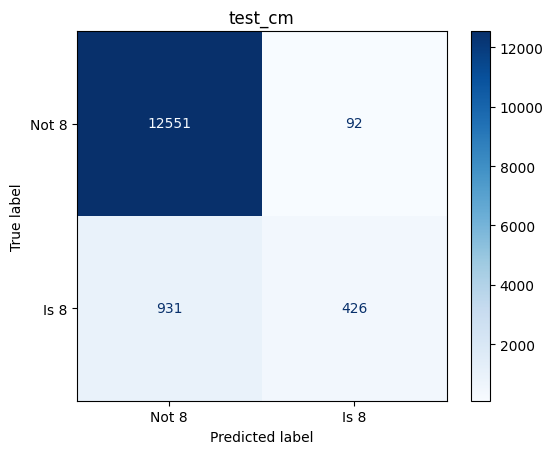

In [17]:
import matplotlib.pyplot as plt
train_cm = confusion_matrix(y_train, y_pred_train)
test_cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=train_cm, display_labels=["Not 8", "Is 8"])
disp.plot(cmap=plt.cm.Blues)
plt.title("train_cm")
plt.show()
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=["Not 8", "Is 8"])
disp.plot(cmap=plt.cm.Blues)
plt.title("test_cm")
plt.show()